In [ ]:
## 05 — Transformer Prep (MIMIC-IV ICD Coding)

# This notebook prepares data for transformer training:
# - Load final modeling dataset (discharge summaries + top-50 ICD labels)
# - Create reproducible train/val/test splits and save them
# - Analyze token lengths for BERT-like models
# - Choose a long-note strategy (truncate vs chunk)
# - Create Hugging Face Dataset objects and save to disk


In [10]:
# 1. Imports

# If needed:
# !pip install -q transformers datasets accelerate evaluate

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer


In [11]:
# 2. load dataset + basic checks

DATA_PATH = Path("final_modeling_dataset.parquet")
df = pd.read_parquet(DATA_PATH)

df = df.dropna(subset=["text", "icd_code"]).reset_index(drop=True)

print("Rows:", len(df))
print("Unique hadm_id:", df["hadm_id"].nunique())
print("Avg note length (chars):", df["text"].str.len().mean())
print("Avg codes per admission:", df["icd_code"].apply(len).mean())
df.head(2)


Rows: 115103
Unique hadm_id: 115103
Avg note length (chars): 11724.312650408765
Avg codes per admission: 5.369356141890307


,hadm_id,text,icd_code
0,23052089,\nName: ___ Unit No: __...,[E785]
1,22927623,\nName: ___ Unit No: ___\n...,"[K219, F419, Z87891]"


In [13]:
# 3. Reproducible Split (Train/Val/Test) + Save IDs

RANDOM_SEED = 42

X = df["text"]
y = df["icd_code"]
hadm = df["hadm_id"]

# First split off test
X_trainval, X_test, y_trainval, y_test, hadm_trainval, hadm_test = train_test_split(
    X, y, hadm, test_size=0.2, random_state=RANDOM_SEED
)

# Split train/val
X_train, X_val, y_train, y_val, hadm_train, hadm_val = train_test_split(
    X_trainval, y_trainval, hadm_trainval, test_size=0.125, random_state=RANDOM_SEED
)
# 0.125 of 0.8 = 0.1 → final: 70/10/20

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))


Train: 80571 Val: 11511 Test: 23021


In [14]:
# Save split IDs so it can be reconstructed anytime

splits_dir = Path("splits")
splits_dir.mkdir(exist_ok=True)

pd.DataFrame({"hadm_id": hadm_train}).to_csv(splits_dir / "train_hadm_ids.csv", index=False)
pd.DataFrame({"hadm_id": hadm_val}).to_csv(splits_dir / "val_hadm_ids.csv", index=False)
pd.DataFrame({"hadm_id": hadm_test}).to_csv(splits_dir / "test_hadm_ids.csv", index=False)

print("Saved split hadm_ids to:", splits_dir.resolve())


Saved split hadm_ids to: /Users/aaradhyaacharya/Documents/semesters/grad/sem4/ICD_NLP/splits


In [18]:
# 4. Label Binarization

mlb = MultiLabelBinarizer()
Y_train = mlb.fit_transform(y_train)
Y_val   = mlb.transform(y_val)
Y_test  = mlb.transform(y_test)

label_list = list(mlb.classes_)
num_labels = len(label_list)

print("Num labels:", num_labels)
print("Example label set:", label_list[:10])


Num labels: 50
Example label set: ['D62', 'D649', 'D696', 'E039', 'E1122', 'E119', 'E669', 'E785', 'E871', 'E872']


In [20]:
# Save label list for later

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

pd.Series(label_list).to_csv(artifacts_dir / "label_list.csv", index=False, header=["icd_code"])
print("Saved label list to:", (artifacts_dir / "label_list.csv").resolve())


Saved label list to: /Users/aaradhyaacharya/Documents/semesters/grad/sem4/ICD_NLP/artifacts/label_list.csv


In [22]:
# 5. token length analysis

MODEL_CHECKPOINT = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, use_fast=True)

# Many BERT tokenizers have model_max_length = 512
print("Tokenizer max length:", tokenizer.model_max_length)




Tokenizer max length: 1000000000000000019884624838656


In [24]:
# Compute token lengths on a sample (fast), then optionally on full set:

SAMPLE_N = min(5000, len(df))
sample_texts = df["text"].sample(SAMPLE_N, random_state=RANDOM_SEED).tolist()

def token_lengths(texts, batch_size=32):
    lens = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=False, add_special_tokens=True)
        lens.extend([len(ids) for ids in enc["input_ids"]])
    return np.array(lens)

lens = token_lengths(sample_texts, batch_size=32)
lens[:10], lens.mean(), np.percentile(lens, [50, 75, 90, 95, 99])


(array([3382, 3799, 3704, 1448, 1813, 4593, 5434, 2750, 3240, 3217]),
 3433.3572,
 array([3261.  , 4226.  , 5275.5 , 5999.05, 7945.15]))

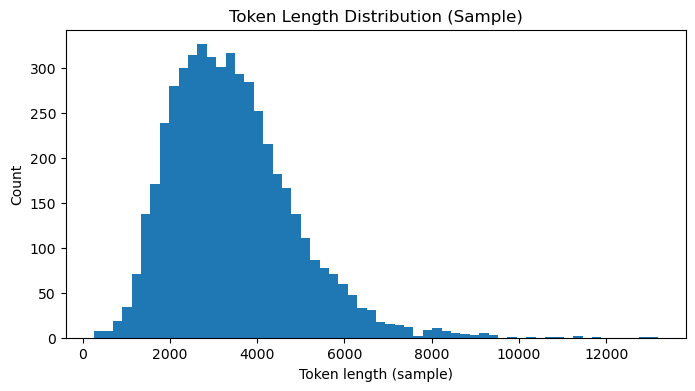

Percent of sampled notes > 512 tokens: 99.80%


In [25]:
# Plot distribution + % that exceed 512:

plt.figure(figsize=(8,4))
plt.hist(lens, bins=60)
plt.xlabel("Token length (sample)")
plt.ylabel("Count")
plt.title("Token Length Distribution (Sample)")
plt.show()

over_512 = (lens > 512).mean()
print(f"Percent of sampled notes > 512 tokens: {over_512*100:.2f}%")


In [26]:
# set a fixed max length and strategy

MAX_LEN = 512
LONG_NOTE_STRATEGY = "truncate"
print("Using strategy:", LONG_NOTE_STRATEGY, "| MAX_LEN =", MAX_LEN)

Using strategy: truncate | MAX_LEN = 512


In [30]:
# build hugging face datasets

def make_df(text_series, y_bin, hadm_series):
    out = pd.DataFrame({
        "hadm_id": hadm_series.values,
        "text": text_series.values,
    })
    out["labels"] = list(y_bin.astype(np.float32))
    return out

train_df = make_df(X_train, Y_train, hadm_train)
val_df   = make_df(X_val, Y_val, hadm_val)
test_df  = make_df(X_test, Y_test, hadm_test)

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head(2)

(80571, 3) (11511, 3) (23021, 3)


,hadm_id,text,labels
0,28227896,\nName: ___ Unit No: ___\n \nAdmis...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,23126432,\nName: ___ Unit No: ___\n \...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [32]:
from datasets import Dataset, DatasetDict

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds = Dataset.from_pandas(val_df, preserve_index=False)
test_ds = Dataset.from_pandas(test_df, preserve_index=False)

ds = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds
})

ds

DatasetDict({
    train: Dataset({
        features: ['hadm_id', 'text', 'labels'],
        num_rows: 80571
    })
    validation: Dataset({
        features: ['hadm_id', 'text', 'labels'],
        num_rows: 11511
    })
    test: Dataset({
        features: ['hadm_id', 'text', 'labels'],
        num_rows: 23021
    })
})

In [34]:
# tokenize with truncation

def tokenize_truncate(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False
    )

tokenized = ds.map(tokenize_truncate, batched=True, remove_columns=["text"])
tokenized

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Map:   0%|          | 0/80571 [00:00<?, ? examples/s]

Map:   0%|          | 0/11511 [00:00<?, ? examples/s]

Map:   0%|          | 0/23021 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['hadm_id', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 80571
    })
    validation: Dataset({
        features: ['hadm_id', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 11511
    })
    test: Dataset({
        features: ['hadm_id', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 23021
    })
})

In [35]:
# set format for PyTorch

tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [36]:
# Save the tokenized dataset

tokenized_dir = Path("hf_datasets") / "tokenized_truncate"
tokenized_dir.mkdir(parents=True, exist_ok=True)

tokenized.save_to_disk(str(tokenized_dir))
print("Saved tokenized dataset to:", tokenized_dir.resolve())

Saving the dataset (0/1 shards):   0%|          | 0/80571 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/11511 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/23021 [00:00<?, ? examples/s]

Saved tokenized dataset to: /Users/aaradhyaacharya/Documents/semesters/grad/sem4/ICD_NLP/hf_datasets/tokenized_truncate


In [37]:
# Save support label and optional class weights

label_support_train = Y_train.sum(axis=0)

support_df = pd.DataFrame({
    "icd_code": label_list,
    "train_support": label_support_train.astype(int)
}).sort_values("train_support", ascending=False)

support_df.head(10)

,icd_code,train_support
7,E785,30859
16,I10,30614
47,Z87891,25524
29,K219,21510
11,F329,16092
20,I2510,15873
32,N179,13748
12,F419,13366
42,Z7901,10752
44,Z794,10676


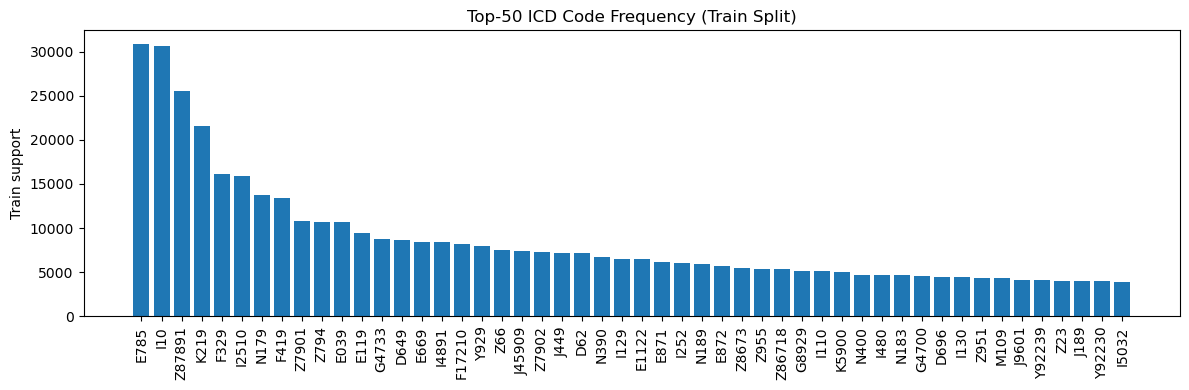

In [38]:
plt.figure(figsize=(12,4))
plt.bar(support_df["icd_code"], support_df["train_support"])
plt.xticks(rotation=90)
plt.ylabel("Train support")
plt.title("Top-50 ICD Code Frequency (Train Split)")
plt.tight_layout()
plt.show()

In [39]:
support_df.to_csv(artifacts_dir / "train_label_support.csv", index=False)
print("Saved label support to:", (artifacts_dir / "train_label_support.csv").resolve())

Saved label support to: /Users/aaradhyaacharya/Documents/semesters/grad/sem4/ICD_NLP/artifacts/train_label_support.csv


In [40]:
pos = label_support_train
neg = len(Y_train) - pos
pos_weight = (neg / np.maximum(pos, 1)).astype(np.float32)

np.save(artifacts_dir / "pos_weight.npy", pos_weight)
print("Saved pos_weight to:", (artifacts_dir / "pos_weight.npy").resolve())

Saved pos_weight to: /Users/aaradhyaacharya/Documents/semesters/grad/sem4/ICD_NLP/artifacts/pos_weight.npy
